In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns




In [5]:
df=pd.read_csv("smartcart_customers.csv")

In [7]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

Data Preprocessing

In [10]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [12]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

Feature Engineering

In [15]:
df["Age"]=2026-df["Year_Birth"]

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [19]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
referance_date=df["Dt_Customer"].max()
df["Customer_tenure_Days"]=(referance_date -df["Dt_Customer"]).dt.days


In [21]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_Days'],
      dtype='str')

In [23]:
df["Total_spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [25]:
df["Total_children"]=df["Kidhome"]+df["Teenhome"]

In [27]:

df["Education"]=df["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate","Graduation":"Graduate",
                         "Master":"Postgraduate","PhD":"Postgraduate"})

In [29]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [31]:
df["Living_with"]=df["Marital_Status"].replace({"Married":"Partner","Together":"Partner",
                                         "Single":"Alone",
                         "Divorced":"Alone","Widow":"Alone"
                            ,"Alone":"Alone","Absurd":"Alone","YOLO":"Alone"})

In [33]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_Days', 'Total_spending',
       'Total_children', 'Living_with'],
      dtype='str')

Drop Columns

In [36]:
d_col=["ID", "Year_Birth","Marital_Status","Kidhome","Teenhome","MntWines","MntFruits","Dt_Customer","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
df_cleaned=df.drop(columns=d_col)

In [38]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2240 non-null   str    
 1   Income                2240 non-null   float64
 2   Recency               2240 non-null   int64  
 3   NumDealsPurchases     2240 non-null   int64  
 4   NumWebPurchases       2240 non-null   int64  
 5   NumCatalogPurchases   2240 non-null   int64  
 6   NumStorePurchases     2240 non-null   int64  
 7   NumWebVisitsMonth     2240 non-null   int64  
 8   Complain              2240 non-null   int64  
 9   Response              2240 non-null   int64  
 10  Age                   2240 non-null   int64  
 11  Customer_tenure_Days  2240 non-null   int64  
 12  Total_spending        2240 non-null   int64  
 13  Total_children        2240 non-null   int64  
 14  Living_with           2240 non-null   str    
dtypes: float64(1), int64(12), str(2)

Outliers

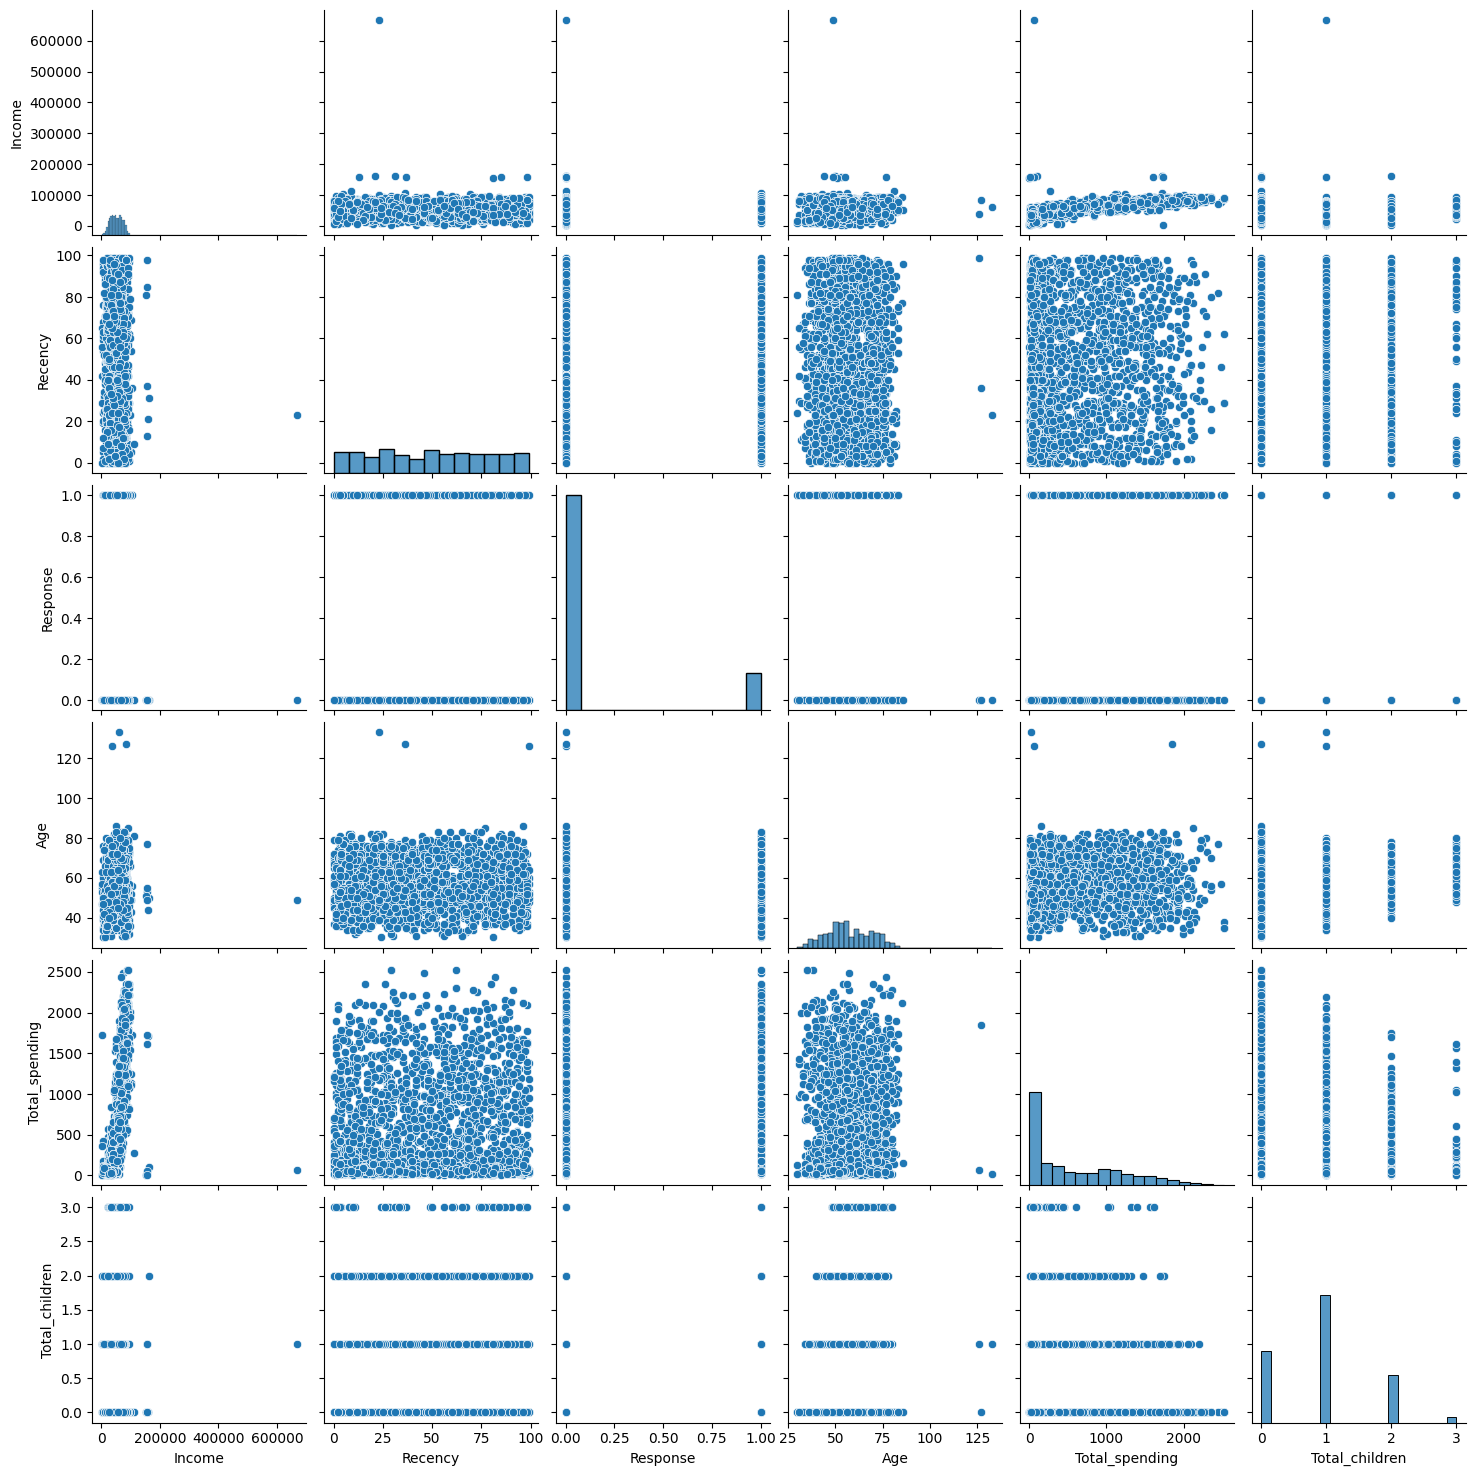

In [41]:
cols = ["Income", "Recency", "Response", "Age", "Total_spending", "Total_children"]

# relative plots of some features-  pair plots
sns.pairplot(df_cleaned[cols])

In [43]:
print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


Heatmap


In [46]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

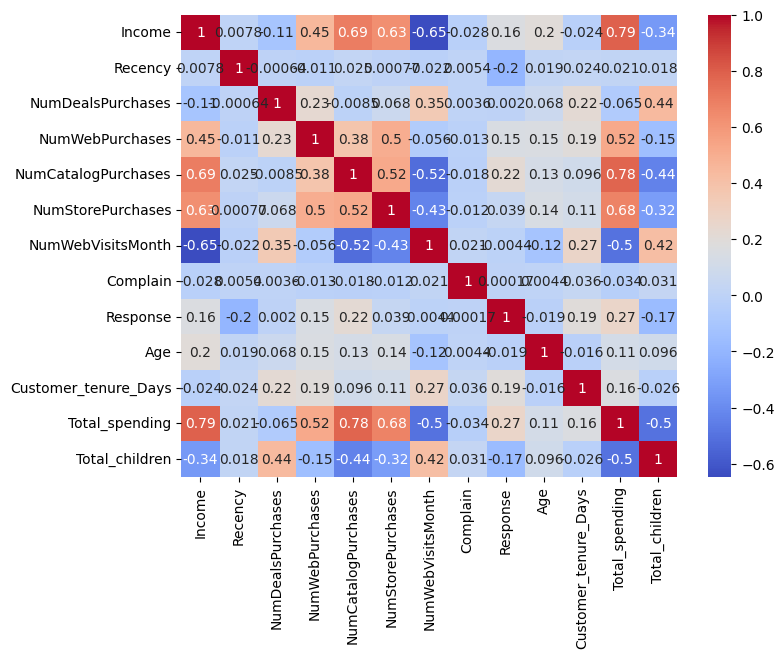

In [48]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    
    cmap="coolwarm"
)

Encoding

In [51]:
from sklearn.preprocessing import OneHotEncoder

In [59]:
ohe=OneHotEncoder()

catagorical_col=["Education","Living_with"]
enc_col=ohe.fit_transform(df_cleaned[catagorical_col])
enc_df=pd.DataFrame(enc_col.toarray(),columns=ohe.get_feature_names_out(catagorical_col),index=df_cleaned.index)

In [61]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [65]:
df_encoded=pd.concat([df_cleaned.drop(columns=catagorical_col),enc_df],axis=1)

Scaling

In [68]:
from  sklearn.preprocessing import StandardScaler

In [170]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df_encoded)
X=df_encoded

Visualize

In [92]:
#2D
from sklearn.decomposition import PCA
pca=PCA(n_components=3)

x_pca=pca.fit_transform(x_scaled)

In [94]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

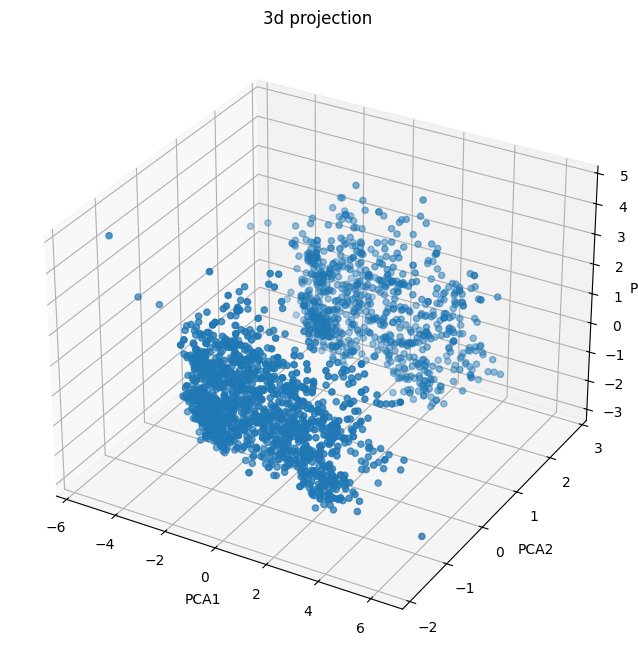

In [102]:
#plot
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

#Analyze K value


#1.Elbow Method

In [124]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [122]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [128]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow
print("Optimal K=",optimal_k)

Optimal K= 4


Text(0, 0.5, 'WCSS')

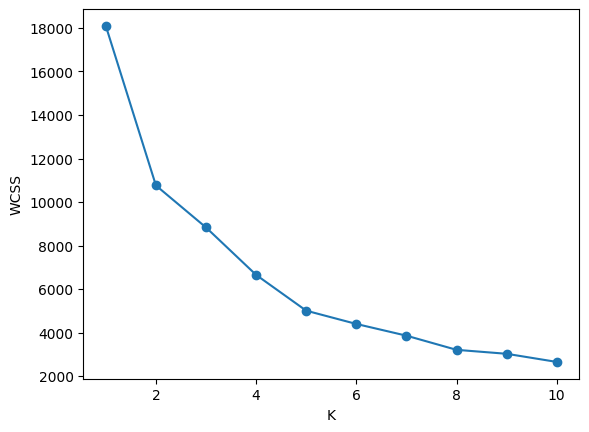

In [131]:
# plot

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

2.Silhouette Score

Text(0, 0.5, 'Silhouette score')

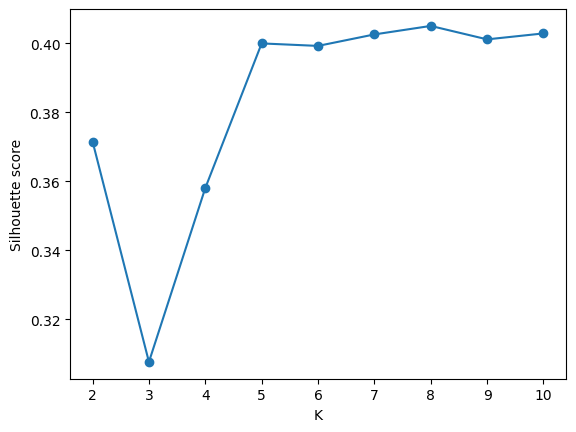

In [135]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

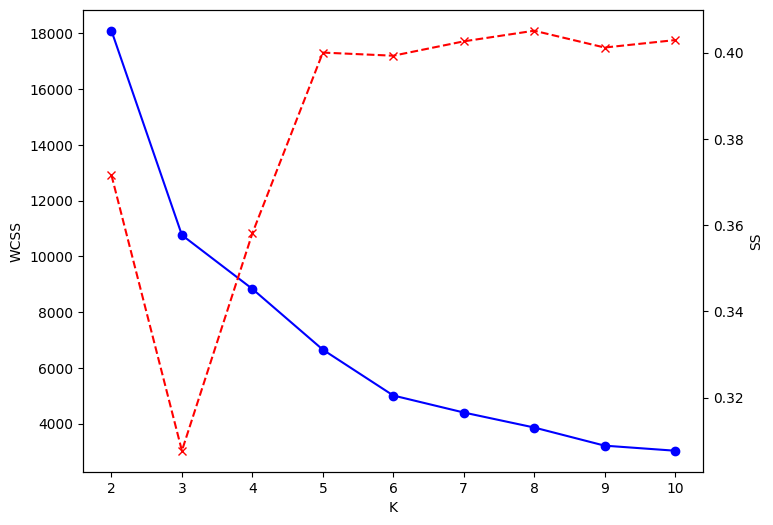

In [137]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

Clustering

In [140]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(x_pca)

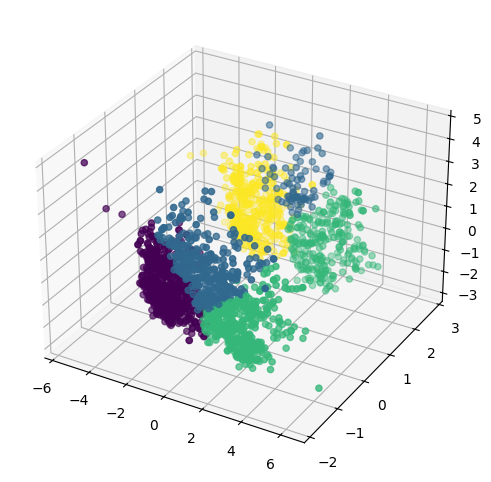

In [146]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], c=labels_kmeans)

In [150]:
from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(x_pca)

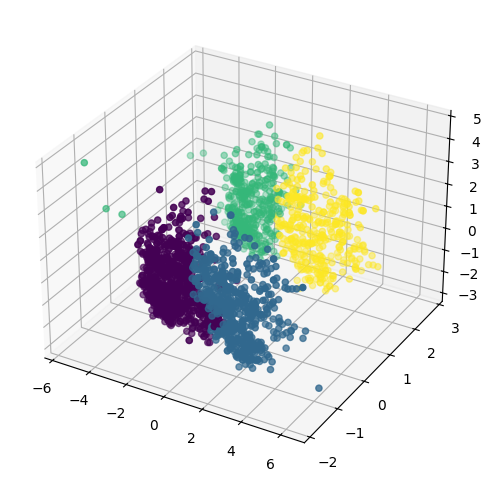

In [152]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], c=labels_agg)

In [172]:
X["cluster"] = labels_agg

<Axes: xlabel='cluster', ylabel='count'>

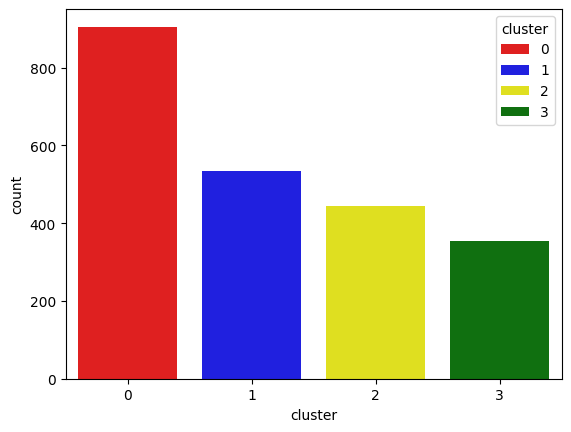

In [174]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

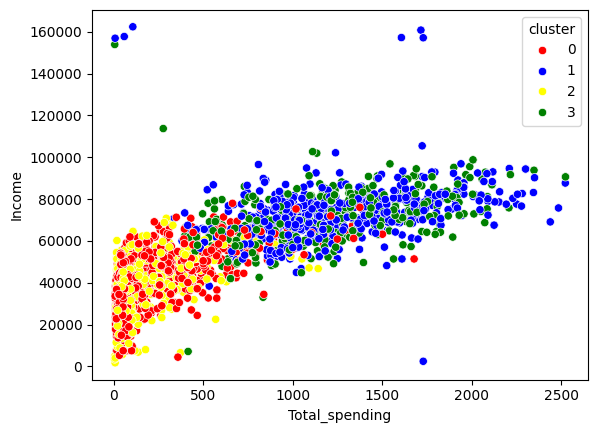

In [179]:
# Income & Spending patterns

sns.scatterplot(x=X["Total_spending"], y=X["Income"], hue=X["cluster"], palette=pal)

Cluster summary

In [181]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_tenure_Days  Total_spending  \
cluster         